# Cyclists' Perception of Overall Cycling Quality — Ordered Probability Model
### Ordered logit vs ordered probit · full vs refined specification · diagnostics & robustness

**Question:** which cyclist, household, access and neighbourhood characteristics explain how a cyclist rates the
*overall quality of cycling routes and facilities* (`Rank_Overall-Quality-Of-Biking`, survey q1)?

**Data:** `CyclingPerceptionData.xlsx` (sheet `Final`) — survey of Toronto bicycle owners.

The dependent variable is an **ordinal** rating, so an ordered response model is used:

$$y^* = x'\beta + \varepsilon,\qquad y = k \iff \mu_{k-1} < y^* \le \mu_k,\qquad
P(y\le k)=F(\mu_k - x'\beta)$$

with $F$ = logistic (ordered **logit**) or standard normal (ordered **probit**). Every interpretation printed below is
computed from the fitted models, not hard-coded.

| Part | Sections |
|---|---|
| **Setup & data** | 1 Setup · 2 Load & audit · 3 Preparation · 4 Exploration |
| **Estimation** | 5 Full model (logit & probit) · 6 Logit vs probit · 7 Refined model |
| **Interpretation** | 8 Odds ratios & thresholds · 9 Marginal effects on probabilities |
| **Validation** | 10 Fit & prediction · 11 Proportional-odds (Brant) test · 12 Robustness · 13 Summary |

> **Assumptions to confirm** (the workbook's `Variables` sheet is truncated, so these are inferred — see section 2):
> the rating scale runs **1 = Excellent … 5 = Poor**, and code **6** (only 2 respondents) is merged into 5.
> To flip the direction, change `HIGHER_IS_WORSE` in section 1.

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

SRC_PATH = "CyclingPerceptionData.xlsx"
ALPHA = 0.05
HIGHER_IS_WORSE = True     # survey codes: 1 = Excellent ... 5 = Poor (assumption; Variables sheet is truncated)
DROP_P = 0.10              # backward-elimination threshold for the refined model
RNG = np.random.default_rng(42)

# one hue + neutrals (charts below are single-series or small multiples, no rainbow)
INK, MUTED, GRID, ACCENT = "#1f2933", "#6b7785", "#e3e7eb", "#2b6cb0"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "figure.dpi": 110, "font.size": 10,
})

## 2. Load & Audit
Check the raw file before trusting anything downstream: duplicates, outliers, constants and undocumented codes.

In [2]:
raw = pd.read_excel(SRC_PATH, sheet_name="Final")
print(f"Loaded {raw.shape[0]} rows x {raw.shape[1]} columns | missing cells: {int(raw.isna().sum().sum())}")

n_dup = int(raw.duplicated().sum())
vc = raw["ID"].value_counts()
print(f"\nExact duplicate rows : {n_dup}  ->  {raw.drop_duplicates().shape[0]} unique respondents")
print("Most repeated IDs    :", vc[vc > 1].head(4).to_dict())
print("IDs still repeated after dropping exact duplicates:", int(raw.drop_duplicates()["ID"].duplicated().sum()))

print("\nConstant columns     :", [c for c in raw.columns if raw[c].nunique() == 1])
o = raw["BikingForErrndFriends"]
print(f"BikingForErrndFriends: max={o.max()}, 2nd largest={o.nlargest(2).iloc[-1]}  -> outlier")

print("\nRaw distribution of the dependent variable (1 = Excellent ... 6):")
print(raw["Rank_Overall-Quality-Of-Biking"].value_counts().sort_index().to_string())

Loaded 243 rows x 31 columns | missing cells: 0

Exact duplicate rows : 36  ->  207 unique respondents
Most repeated IDs    : {41066: 20, 41451: 5, 40736: 3, 40929: 2}
IDs still repeated after dropping exact duplicates: 0

Constant columns     : ['OwnBikes']
BikingForErrndFriends: max=101, 2nd largest=5  -> outlier

Raw distribution of the dependent variable (1 = Excellent ... 6):
1    15
2    35
3    68
4    83
5    40
6     2


**Decisions taken from the audit**

| Issue | Treatment | Why |
|---|---|---|
| Exact duplicate rows | Dropped | Repeated copies of one respondent (one ID appears 20×) would overweight that person and overstate precision. Robustness check in §12 keeps them. |
| `BikingForErrndFriends = 101` | Capped at the next-largest value | Almost certainly a keying error; one point would otherwise dominate the coefficient. |
| Rating category 6 (n = 2) | Merged into 5 | A category with 2 observations cannot support its own threshold. Robustness check in §12 drops them instead. |
| `OwnBikes` | Excluded | Constant (all respondents own a bike). |
| Category codes | Taken from header cell comments | The `Variables` sheet does not contain them; they are in comments on columns N, P, R, S, T, U. |

## 3. Data Preparation
Short names, dependent variable oriented so **higher = better quality**, and recodes of the categorical
survey fields into interpretable dummies. Built as a function so the robustness checks (§12) reuse identical logic.

In [3]:
def prepare(src, dedupe=True, merge6=True, cap_errands=True):
    d = src.drop_duplicates().copy() if dedupe else src.copy()
    d = d.reset_index(drop=True)

    r = d["Rank_Overall-Quality-Of-Biking"]
    r = r.clip(upper=5) if merge6 else r
    d = d[r.notna()].copy() if merge6 else d.copy()
    if not merge6:                                  # drop the 2 respondents coded 6
        d = d[r <= 5].copy(); r = r[r <= 5]
    d["Rating_raw"] = r.loc[d.index]
    d["Quality"] = (6 - d["Rating_raw"]) if HIGHER_IS_WORSE else d["Rating_raw"]   # 5 = best

    car = d["AccessToMotorVehicle_1Yes-2No-3Unknown"]        # 1 all the time ... 4 never (cell comment)
    home = d["d3: Home Type"]; job = d["d6: Job Stastus"]
    d["Male"]        = d["sex"]
    d["Age10"]       = d["age"] / 10                          # per decade
    d["NBikes"]      = d["NumberOfBikes"]
    d["Adults"]      = d["HH_Adults_15+"]
    d["Kids"]        = (d["HH_Children_Dummy"] == 2).astype(int)   # 2 = children present (inferred coding)
    d["WorkTrips"]   = d["BikingForWork"]
    d["SchoolTrips"] = d["BikingForSchool"]
    e = d["BikingForErrndFriends"]
    d["ErrandTrips"] = e.clip(upper=e[e < 100].max()) if cap_errands else e
    d["RecBikers"]   = d["Num of Recreational-Biker"]
    d["CarAlways"]   = (car == 1).astype(int)
    d["ParkWork"]    = (d["BikeParkingAt Work_1Yes2No3Unknown"] == 1).astype(int)
    d["YrsNH"]       = d["How longLivedInNH"]                 # 1 (<1 yr) ... 5 (>10 yrs)
    d["Own"]         = (d["Home_1Rent2Own"] == 2).astype(int)
    d["Detached"]    = (home == 1).astype(int)
    d["UnivGrad"]    = (d["d5: LevelOfEducation"] >= 6).astype(int)   # completed university or graduate degree
    d["Income"]      = d["d8: Income"]                        # 1 (<$20k) ... 7 (>=$120k)
    d["Student"]     = (job == 7).astype(int)
    d["Retired"]     = (job == 4).astype(int)
    d["tPath"]       = d["Time from MajorBikePath_min"]
    d["tLane"]       = d["Time from Neasrest BikeLane_Min"]
    d["BikeDens"]    = d["Neighbourhood-bikeLength_KM"] / d["Neighbourhood-Area_SQKM"]        # km per km2
    d["PopDens"]     = d["Neighbourhood_Population"] / d["Neighbourhood-Area_SQKM"] / 1000     # '000 per km2
    d["LanePerK"]    = d["Neighbourhood-bikeLength_KM"] / d["Neighbourhood_Population"] * 1000 # km per '000 people
    return d

df = prepare(raw)
X_ALL = ["Male","Age10","NBikes","Adults","Kids","WorkTrips","SchoolTrips","ErrandTrips","RecBikers",
         "CarAlways","ParkWork","YrsNH","Own","Detached","UnivGrad","Income","Student","Retired",
         "tPath","tLane","BikeDens","PopDens","LanePerK"]

LABELS = {
 "Male":"Male (1 = male)", "Age10":"Age (per 10 years)", "NBikes":"Number of bikes owned",
 "Adults":"Adults (15+) in household", "Kids":"Children in household (1 = yes)",
 "WorkTrips":"Household cyclists biking for work", "SchoolTrips":"Household cyclists biking for school",
 "ErrandTrips":"Household cyclists biking for errands/friends", "RecBikers":"Household recreational cyclists",
 "CarAlways":"Car available all the time (1 = yes)", "ParkWork":"Bike parking at work (1 = yes)",
 "YrsNH":"Years in neighbourhood (1-5 band)", "Own":"Owns home (1 = yes)", "Detached":"Detached/semi-detached home",
 "UnivGrad":"University graduate (1 = yes)", "Income":"Income band (1-7)", "Student":"Student (1 = yes)",
 "Retired":"Retired (1 = yes)", "tPath":"Minutes to major bike path", "tLane":"Minutes to nearest bike lane",
 "BikeDens":"Bike-network density (km/km2)", "PopDens":"Population density ('000/km2)",
 "LanePerK":"Bike km per '000 residents"}

print(f"Analysis sample: N = {len(df)}")
print("Quality (5 = best if HIGHER_IS_WORSE, i.e. 6 - rating):")
print(df["Quality"].value_counts().sort_index().to_string())

Analysis sample: N = 207
Quality (5 = best if HIGHER_IS_WORSE, i.e. 6 - rating):
1    42
2    61
3    61
4    29
5    14


## 4. Exploration
Distribution of the rating and how the raw (pre-model) mean rating moves with the main candidate drivers.

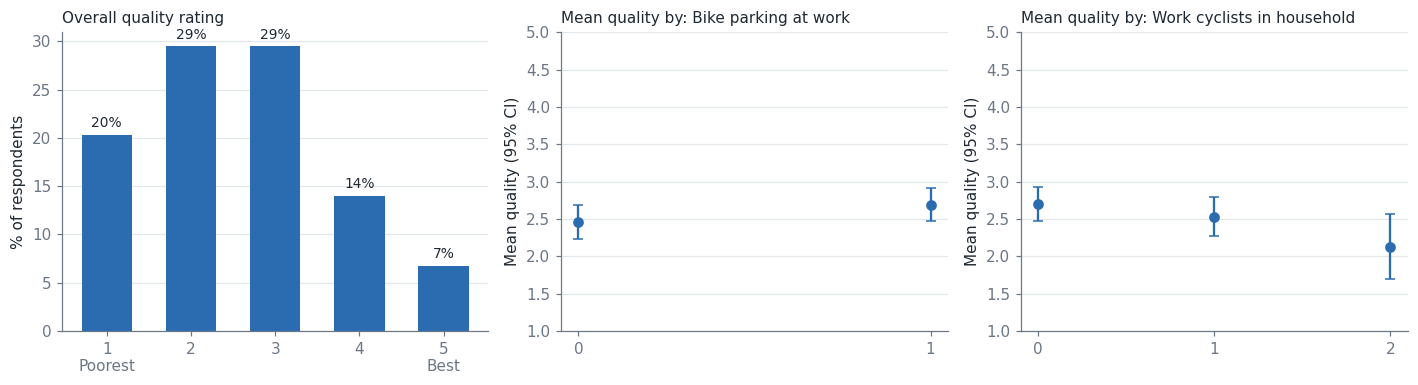

Correlation of candidate predictors with Quality (Spearman):


,rho
UnivGrad,-0.163
WorkTrips,-0.130
ErrandTrips,-0.115
tPath,-0.111
PopDens,-0.108
ParkWork,0.108
tLane,-0.102
Income,-0.077
Detached,-0.074
YrsNH,-0.071


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={"width_ratios":[1.1,1,1]})

# (a) distribution of dependent variable
cats = sorted(df["Quality"].unique())
share = df["Quality"].value_counts(normalize=True).reindex(cats) * 100
names = {1:"1\nPoorest", 2:"2", 3:"3", 4:"4", 5:"5\nBest"} if HIGHER_IS_WORSE else {k:str(k) for k in cats}
ax[0].bar([names[c] for c in cats], share.values, color=ACCENT, width=0.6)
for i, v in enumerate(share.values): ax[0].text(i, v + 0.8, f"{v:.0f}%", ha="center", color=INK, fontsize=9)
ax[0].set_title("Overall quality rating", loc="left", fontsize=10); ax[0].set_ylabel("% of respondents")
ax[0].grid(axis="x", visible=False)

# (b,c) mean quality by two key predictors
for a, (col, lab) in zip(ax[1:], [("ParkWork","Bike parking at work"), ("WorkTrips","Work cyclists in household")]):
    g = df.groupby(col)["Quality"].agg(["mean","count","std"])
    g = g[g["count"] >= 5]
    se = g["std"] / np.sqrt(g["count"])
    a.errorbar(g.index.astype(str), g["mean"], yerr=1.96*se, fmt="o", color=ACCENT, capsize=3, lw=1.5, ms=6)
    a.set_title(f"Mean quality by: {lab}", loc="left", fontsize=10); a.set_ylabel("Mean quality (95% CI)")
    a.set_ylim(1, 5); a.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("Correlation of candidate predictors with Quality (Spearman):")
sp = pd.Series({c: st.spearmanr(df[c], df["Quality"])[0] for c in X_ALL}).sort_values(key=abs, ascending=False)
display(sp.head(10).to_frame("rho"))

In [5]:
# Multicollinearity screen on the full candidate set
Xc = sm.add_constant(df[X_ALL].astype(float))
vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])], index=X_ALL)
pairs = df[X_ALL].corr().abs().where(np.triu(np.ones((len(X_ALL),)*2), 1).astype(bool)).stack()
print(f"Max VIF = {vif.max():.2f} ({vif.idxmax()}) -> {'no serious' if vif.max() < 5 else 'some'} multicollinearity (rule of thumb: VIF > 5-10)")
print("Highest pairwise |r|:")
display(pairs.sort_values(ascending=False).head(4).to_frame("|r|"))

Max VIF = 3.26 (LanePerK) -> no serious multicollinearity (rule of thumb: VIF > 5-10)
Highest pairwise |r|:


,,|r|
BikeDens,LanePerK,0.602
Age10,Retired,0.562
Own,Detached,0.558
NBikes,RecBikers,0.540


## 5. Full Model — Ordered Logit and Ordered Probit
All 23 candidate variables. `OrderedModel` reports thresholds as: first cut-point, then the **log of each successive gap**
(so the gaps stay positive); §8 converts these back to actual cut-points $\mu_1..\mu_4$.

In [6]:
def fit_om(data, cols, dist="logit", **kw):
    return OrderedModel(data["Quality"], data[cols], distr=dist).fit(method="bfgs", disp=0, maxiter=5000, **kw)

def coef_table(res, cols, label=None):
    t = pd.DataFrame({"coef": res.params[cols], "std err": res.bse[cols], "z": res.tvalues[cols], "p": res.pvalues[cols]})
    t["sig"] = np.select([t.p < .01, t.p < .05, t.p < .10], ["***","**","*"], "")
    if label: t.index = [LABELS[i] for i in t.index]
    return t

full_logit  = fit_om(df, X_ALL, "logit")
full_probit = fit_om(df, X_ALL, "probit")
print("FULL ORDERED LOGIT"); display(coef_table(full_logit, X_ALL, label=True))
print("FULL ORDERED PROBIT"); display(coef_table(full_probit, X_ALL, label=True))

FULL ORDERED LOGIT


,coef,std err,z,p,sig
Male (1 = male),0.062,0.270,0.228,0.819,
Age (per 10 years),-0.016,0.121,-0.131,0.895,
Number of bikes owned,-0.012,0.148,-0.083,0.934,
Adults (15+) in household,0.006,0.146,0.039,0.969,
Children in household (1 = yes),0.420,0.317,1.327,0.184,
Household cyclists biking for work,-0.564,0.196,-2.875,0.004,***
Household cyclists biking for school,0.095,0.242,0.392,0.695,
Household cyclists biking for errands/friends,-0.275,0.176,-1.562,0.118,
Household recreational cyclists,0.154,0.190,0.806,0.420,
Car available all the time (1 = yes),-0.205,0.298,-0.689,0.491,


FULL ORDERED PROBIT


,coef,std err,z,p,sig
Male (1 = male),0.008,0.156,0.048,0.961,
Age (per 10 years),-0.005,0.073,-0.067,0.947,
Number of bikes owned,-0.027,0.088,-0.304,0.761,
Adults (15+) in household,-0.017,0.086,-0.198,0.843,
Children in household (1 = yes),0.205,0.184,1.112,0.266,
Household cyclists biking for work,-0.344,0.119,-2.898,0.004,***
Household cyclists biking for school,0.039,0.144,0.274,0.784,
Household cyclists biking for errands/friends,-0.146,0.107,-1.364,0.172,
Household recreational cyclists,0.106,0.116,0.913,0.361,
Car available all the time (1 = yes),-0.125,0.175,-0.715,0.474,


## 6. Logit vs Probit
Both have the same number of parameters, so the log-likelihood / AIC comparison is direct. Logit coefficients are
typically ≈ 1.6–1.8 × probit coefficients purely because of the different error scale, so *sign and significance*,
not magnitude, should agree.

In [7]:
def fit_stats(res, n=None):
    n = n or int(res.nobs)
    return {"LogLik": res.llf, "AIC": res.aic, "BIC": res.bic, "k": len(res.params)}

cmp = pd.DataFrame({"Logit": fit_stats(full_logit), "Probit": fit_stats(full_probit)}).T
display(cmp)
scale = (full_logit.params[X_ALL] / full_probit.params[X_ALL])
same_sign = (np.sign(full_logit.params[X_ALL]) == np.sign(full_probit.params[X_ALL])).mean()
sig_l = set(full_logit.pvalues[X_ALL].index[full_logit.pvalues[X_ALL] < ALPHA])
sig_p = set(full_probit.pvalues[X_ALL].index[full_probit.pvalues[X_ALL] < ALPHA])
print(f"Coefficients with the same sign          : {same_sign:.0%}")
print(f"Median logit/probit coefficient ratio    : {scale[scale.abs() < 20].median():.2f}  (theory ~1.6-1.8)")
print(f"Significant at 5% in both / logit only / probit only: {sorted(sig_l & sig_p)} / {sorted(sig_l - sig_p)} / {sorted(sig_p - sig_l)}")
better = "logit" if full_logit.aic < full_probit.aic else "probit"
print(f"AIC difference = {abs(full_logit.aic - full_probit.aic):.2f} in favour of {better} "
      f"-> {'the models are essentially equivalent' if abs(full_logit.aic - full_probit.aic) < 2 else 'a slight edge (not decisive)'}; the same variables are significant under both links, so the link does not drive the conclusions.")

,LogLik,AIC,BIC,k
Logit,-294.751,643.503,733.486,27.000
Probit,-295.963,645.926,735.909,27.000


Coefficients with the same sign          : 96%
Median logit/probit coefficient ratio    : 1.70  (theory ~1.6-1.8)
Significant at 5% in both / logit only / probit only: ['ParkWork', 'UnivGrad', 'WorkTrips', 'tLane'] / [] / []
AIC difference = 2.42 in favour of logit -> a slight edge (not decisive); the same variables are significant under both links, so the link does not drive the conclusions.


## 7. Refined Model
With N ≈ 200 and 23 regressors the full model is over-parameterised. **Backward elimination** removes the
least-significant regressor one at a time until every remaining term has $p \le$ `DROP_P`. The refined model is then
tested against the full model with a likelihood-ratio test (a non-significant LR means the dropped block adds nothing jointly).

*Caveat:* p-values after data-driven selection are optimistic; treat the refined model as a parsimonious summary
and lean on the robustness checks in §12.

In [8]:
def backward(data, cols, dist="logit", thr=DROP_P):
    cols, log = list(cols), []
    while True:
        m = fit_om(data, cols, dist)
        p = m.pvalues[cols]
        if p.max() <= thr or len(cols) == 1: return m, cols, log
        log.append((p.idxmax(), p.max())); cols.remove(p.idxmax())

ref_logit, X_REF, drop_log = backward(df, X_ALL, "logit")
print(f"Retained {len(X_REF)} of {len(X_ALL)} variables: {X_REF}")
print("Elimination order (variable, p at removal):")
print("  " + " | ".join(f"{v} ({p:.2f})" for v, p in drop_log))

ref_probit = fit_om(df, X_REF, "probit")
lr = 2 * (full_logit.llf - ref_logit.llf); dfree = len(X_ALL) - len(X_REF)
print(f"\nLR test refined vs full (logit): chi2({dfree}) = {lr:.2f}, p = {st.chi2.sf(lr, dfree):.3f}  ->  "
      f"{'dropped variables jointly add nothing' if st.chi2.sf(lr, dfree) > ALPHA else 'dropped variables jointly matter'}")
print(f"AIC full {full_logit.aic:.1f} vs refined {ref_logit.aic:.1f} | BIC full {full_logit.bic:.1f} vs refined {ref_logit.bic:.1f}")

# Neighbourhood-clustered SEs (respondents in the same neighbourhood share exposure to the same network)
ref_cl = fit_om(df, X_REF, "logit", cov_type="cluster", cov_kwds={"groups": df["Neighbourhood ID"]})
tab = coef_table(ref_logit, X_REF).join(coef_table(ref_probit, X_REF)[["coef","p"]].add_prefix("probit_"))
tab["cluster SE"] = ref_cl.bse[X_REF]; tab["cluster p"] = ref_cl.pvalues[X_REF]
tab.index = [LABELS[i] for i in tab.index]
print("\nREFINED ORDERED LOGIT (with probit and neighbourhood-clustered checks)")
display(tab)
print(ref_logit.summary().tables[0])

Retained 4 of 23 variables: ['WorkTrips', 'ParkWork', 'UnivGrad', 'tLane']
Elimination order (variable, p at removal):
  Adults (0.97) | PopDens (0.96) | Own (0.94) | NBikes (0.95) | Age10 (0.89) | Male (0.83) | Income (0.78) | Retired (0.77) | Detached (0.68) | SchoolTrips (0.69) | tPath (0.50) | BikeDens (0.45) | LanePerK (0.57) | CarAlways (0.48) | RecBikers (0.29) | ErrandTrips (0.18) | Student (0.13) | Kids (0.19) | YrsNH (0.11)

LR test refined vs full (logit): chi2(19) = 11.88, p = 0.890  ->  dropped variables jointly add nothing
AIC full 643.5 vs refined 617.4 | BIC full 733.5 vs refined 644.0

REFINED ORDERED LOGIT (with probit and neighbourhood-clustered checks)


,coef,std err,z,p,sig,probit_coef,probit_p,cluster SE,cluster p
Household cyclists biking for work,-0.477,0.172,-2.770,0.006,***,-0.307,0.004,0.139,0.001
Bike parking at work (1 = yes),0.531,0.258,2.060,0.039,**,0.319,0.035,0.273,0.051
University graduate (1 = yes),-0.649,0.256,-2.534,0.011,**,-0.352,0.019,0.271,0.017
Minutes to nearest bike lane,-0.022,0.009,-2.436,0.015,**,-0.013,0.019,0.007,0.002


                             OrderedModel Results                             
Dep. Variable:                Quality   Log-Likelihood:                -300.69
Model:                   OrderedModel   AIC:                             617.4
Method:            Maximum Likelihood   BIC:                             644.0
Date:                Mon, 21 Sep 2026                                         
Time:                        16:39:23                                         
No. Observations:                 207                                         
Df Residuals:                     199                                         
Df Model:                           8                                         


## 8. Interpretation — Odds Ratios and Thresholds
In the ordered logit, $\exp(\beta)$ is the **proportional odds ratio**: the multiplicative change in the odds of a
*better* rating (vs. a worse one, at any cut-point) for a one-unit increase in the variable.

In [9]:
def cutpoints(res):
    return res.model.transform_threshold_params(res.params)[1:-1]

ci = ref_logit.conf_int().loc[X_REF]
orr = pd.DataFrame({"Odds ratio": np.exp(ref_logit.params[X_REF]),
                    "95% CI low": np.exp(ci[0]), "95% CI high": np.exp(ci[1]),
                    "p": ref_logit.pvalues[X_REF]})
orr.index = [LABELS[i] for i in orr.index]
display(orr)

for v in X_REF:
    b, p = ref_logit.params[v], ref_logit.pvalues[v]
    if p >= ALPHA: continue
    pct = (np.exp(b) - 1) * 100
    print(f"- {LABELS[v]}: each +1 changes the odds of a better overall rating by {pct:+.0f}% (p = {p:.3f}) "
          f"-> {'improves' if b > 0 else 'lowers'} perceived quality.")

cp = cutpoints(ref_logit)
print("\nEstimated cut-points (latent-scale):", ", ".join(f"mu{i+1} = {c:.2f}" for i, c in enumerate(cp)))

,Odds ratio,95% CI low,95% CI high,p
Household cyclists biking for work,0.621,0.443,0.870,0.006
Bike parking at work (1 = yes),1.701,1.026,2.820,0.039
University graduate (1 = yes),0.522,0.316,0.863,0.011
Minutes to nearest bike lane,0.979,0.962,0.996,0.015


- Household cyclists biking for work: each +1 changes the odds of a better overall rating by -38% (p = 0.006) -> lowers perceived quality.
- Bike parking at work (1 = yes): each +1 changes the odds of a better overall rating by +70% (p = 0.039) -> improves perceived quality.
- University graduate (1 = yes): each +1 changes the odds of a better overall rating by -48% (p = 0.011) -> lowers perceived quality.
- Minutes to nearest bike lane: each +1 changes the odds of a better overall rating by -2% (p = 0.015) -> lowers perceived quality.

Estimated cut-points (latent-scale): mu1 = -2.08, mu2 = -0.61, mu3 = 0.83, mu4 = 2.14


## 9. Marginal Effects on Category Probabilities
Odds ratios say little about *how many people* change their rating. The **average marginal effect (AME)** is the average
change in the predicted probability of each rating category when a variable moves by a stated amount, all else as observed
(dummies: 0→1; others: `+delta`). 95 % intervals come from 5,000 draws from the estimated coefficient distribution
(Krinsky–Robb simulation).

In [10]:
DELTA = {v: 1.0 for v in X_REF}
if "tLane" in DELTA: DELTA["tLane"] = 10.0      # report per +10 minutes (per +1 minute the effect is tiny)
if "tPath" in DELTA: DELTA["tPath"] = 10.0
if "Age10" in DELTA: DELTA["Age10"] = 1.0

def ame_draws(res, cols, var, delta, params):
    Xm = res.model.exog.copy(); j = cols.index(var)
    Xh = Xm.copy(); Xh[:, j] = Xm[:, j] + delta
    return (res.model.predict(params, exog=Xh) - res.model.predict(params, exog=Xm)).mean(axis=0)

def ame_table(res, cols, ndraw=5000):
    draws = RNG.multivariate_normal(res.params.values, res.cov_params().values, size=ndraw)
    K = res.model.k_levels if hasattr(res.model, "k_levels") else len(np.unique(res.model.endog))
    rows = []
    for v in cols:
        point = ame_draws(res, cols, v, DELTA[v], res.params.values)
        sims = np.array([ame_draws(res, cols, v, DELTA[v], p) for p in draws])
        lo, hi = np.percentile(sims, [2.5, 97.5], axis=0)
        for k in range(K):
            rows.append({"var": v, "cat": k + 1, "ame": point[k], "lo": lo[k], "hi": hi[k]})
    return pd.DataFrame(rows)

ame = ame_table(ref_logit, X_REF)
cat_lab = {1:"Poorest (1)", 2:"2", 3:"3 (middle)", 4:"4", 5:"Best (5)"}
piv = ame.assign(txt=lambda t: t.apply(lambda r: f"{r.ame*100:+.1f} [{r.lo*100:+.1f}, {r.hi*100:+.1f}]", axis=1)) \
         .pivot(index="var", columns="cat", values="txt").loc[X_REF]
piv.index = [f"{LABELS[v]}  ({'0→1' if set(df[v].unique()) <= {0,1} else '+' + format(DELTA[v], 'g')})" for v in piv.index]
piv.columns = [cat_lab[c] for c in piv.columns]
print("Change in probability of each rating (percentage points) [95% interval]")
display(piv)

Change in probability of each rating (percentage points) [95% interval]


,Poorest (1),2,3 (middle),4,Best (5)
Household cyclists biking for work (+1),"+8.2 [+2.2, +14.6]","+2.8 [+0.7, +4.5]","-4.5 [-8.0, -1.1]","-4.0 [-6.7, -1.2]","-2.4 [-4.5, -0.7]"
Bike parking at work (1 = yes) (0→1),"-7.0 [-12.1, -0.3]","-5.2 [-10.2, -0.2]","+2.8 [-0.0, +4.6]","+5.3 [+0.2, +10.3]","+4.1 [+0.1, +10.4]"
University graduate (1 = yes) (0→1),"+11.6 [+2.4, +21.9]","+3.1 [+0.2, +4.9]","-6.4 [-11.6, -1.3]","-5.3 [-8.7, -1.3]","-3.1 [-5.6, -0.8]"
Minutes to nearest bike lane (+10),"+3.5 [+0.6, +6.6]","+1.5 [+0.3, +2.8]","-1.9 [-3.6, -0.3]","-1.9 [-3.6, -0.3]","-1.2 [-2.5, -0.2]"


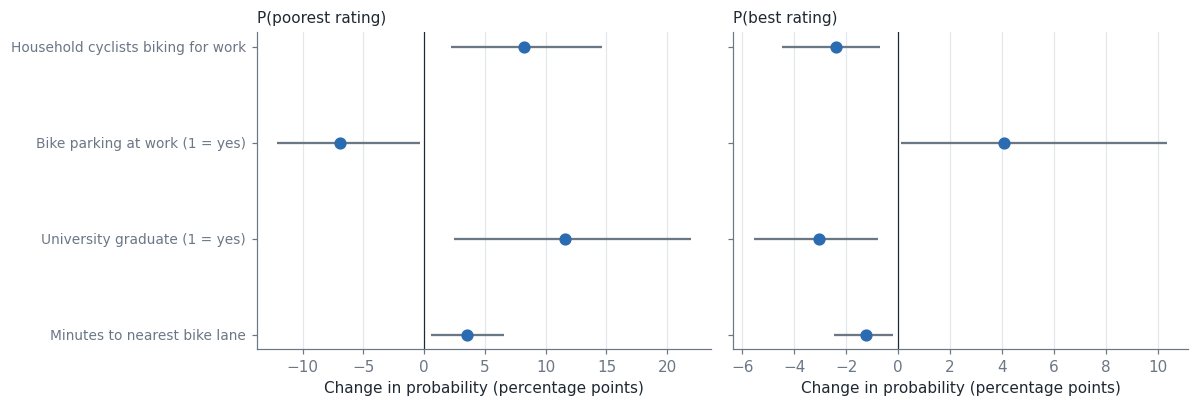

Deltas: dummies 0->1; counts +1; minutes-to-lane/path +10.


In [11]:
# Forest plot: effect on P(best rating) and P(poorest rating), the two tails people care about
fig, axes = plt.subplots(1, 2, figsize=(11, 0.55*len(X_REF)+1.6), sharey=True)
for a, (cat, ttl) in zip(axes, [(1, "P(poorest rating)"), (5, "P(best rating)")]):
    s = ame[ame.cat == cat].set_index("var").loc[X_REF][::-1]
    y = np.arange(len(s))
    a.hlines(y, s.lo*100, s.hi*100, color=MUTED, lw=1.5)
    a.plot(s.ame*100, y, "o", color=ACCENT, ms=7)
    a.axvline(0, color=INK, lw=0.8)
    a.set_yticks(y); a.set_yticklabels([LABELS[v] for v in s.index], fontsize=9)
    a.set_xlabel("Change in probability (percentage points)"); a.set_title(ttl, loc="left", fontsize=10)
    a.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
print("Deltas: dummies 0->1; counts +1; minutes-to-lane/path +10.")

## 10. Goodness of Fit & Prediction
An ordered model has no OLS-style $R^2$; use likelihood-based measures and classification accuracy against benchmarks.

,LogLik,LR chi2,df,LR p,McFadden R2,McFadden adj R2,Correct (modal) %,Within 1 cat %
Full logit,-294.751,32.028,23.000,0.100,0.052,-0.022,34.783,83.575
Refined logit,-300.694,20.144,4.000,0.000,0.032,0.020,33.816,84.058
Refined probit,-301.212,19.107,4.000,0.001,0.031,0.018,33.816,83.575


Null LogLik = -310.77. Benchmark: always guessing the modal category is right 29% of the time; the modal-prediction rate of an ordered model is a weak yardstick when the outcome is concentrated in the middle categories.


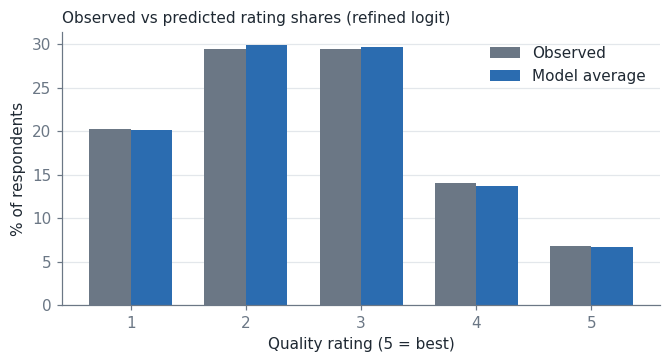

In [12]:
N = len(df)
n_k = df["Quality"].value_counts().sort_index().values
ll_null = float((n_k * np.log(n_k / N)).sum())                 # intercepts-only model
def gof(res, k_slopes):
    ll = res.llf
    mcf = 1 - ll / ll_null
    mcf_adj = 1 - (ll - k_slopes) / ll_null
    lr = 2 * (ll - ll_null); p = st.chi2.sf(lr, k_slopes)
    probs = res.model.predict(res.params.values)
    pred = probs.argmax(axis=1) + 1
    acc = (pred == df["Quality"].values).mean()
    within1 = (np.abs(pred - df["Quality"].values) <= 1).mean()
    return {"LogLik": ll, "LR chi2": lr, "df": k_slopes, "LR p": p, "McFadden R2": mcf,
            "McFadden adj R2": mcf_adj, "Correct (modal) %": acc*100, "Within 1 cat %": within1*100}

g = pd.DataFrame({"Full logit": gof(full_logit, len(X_ALL)), "Refined logit": gof(ref_logit, len(X_REF)),
                  "Refined probit": gof(ref_probit, len(X_REF))}).T
display(g)
print(f"Null LogLik = {ll_null:.2f}. Benchmark: always guessing the modal category is right "
      f"{n_k.max()/N:.0%} of the time; the modal-prediction rate of an ordered model is a weak yardstick "
      "when the outcome is concentrated in the middle categories.")

# predicted vs observed category shares
pr = ref_logit.model.predict(ref_logit.params.values).mean(axis=0)
ob = n_k / N
fig, ax = plt.subplots(figsize=(6.2, 3.4))
x = np.arange(1, 6)
ax.bar(x - 0.18, ob*100, 0.36, color=MUTED, label="Observed")
ax.bar(x + 0.18, pr*100, 0.36, color=ACCENT, label="Model average")
ax.set_xticks(x); ax.set_xlabel("Quality rating (5 = best)"); ax.set_ylabel("% of respondents")
ax.legend(frameon=False); ax.grid(axis="x", visible=False)
ax.set_title("Observed vs predicted rating shares (refined logit)", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 11. Proportional-Odds (Parallel-Lines) Test — Brant
The ordered logit forces every $\beta$ to be identical across cut-points. The Brant test fits a separate binary logit for
each split ($y>1$, $y>2$, …) and Wald-tests whether the slopes are equal. **p < 0.05 for a variable means its effect
differs across parts of the scale**, so a single coefficient is a simplification.

In [13]:
def brant(data, cols, y="Quality"):
    Xd = sm.add_constant(data[cols].astype(float)); Xv = Xd.values
    levels = np.sort(data[y].unique())[:-1]                    # cut after each level except the last
    fits = [sm.Logit((data[y] > c).astype(float), Xd).fit(disp=0) for c in levels]
    J = len(fits); K = Xv.shape[1]
    p = [f.predict(Xd).values for f in fits]
    bs = [f.params.values for f in fits]
    inv = [np.linalg.inv(Xv.T @ (Xv * (pj*(1-pj))[:, None])) for pj in p]
    V = np.zeros((J*K, J*K))
    for j in range(J):
        for k in range(J):
            if j == k: blk = inv[j]
            else:
                a, b = min(j, k), max(j, k)                   # nested events: Cov = p_b (1 - p_a)
                w = p[b] * (1 - p[a])
                blk = inv[j] @ (Xv.T @ (Xv * w[:, None])) @ inv[k]
            V[j*K:(j+1)*K, k*K:(k+1)*K] = blk
    beta = np.concatenate(bs)
    def wald(idx):
        D = []
        for j in range(J-1):
            for i in idx:
                r = np.zeros(J*K); r[j*K+i] = 1; r[(j+1)*K+i] = -1; D.append(r)
        D = np.array(D); d = D @ beta
        stat = float(d @ np.linalg.solve(D @ V @ D.T, d)); return stat, len(D)
    rows = []
    for i, c in enumerate(cols, start=1):
        s, dfree = wald([i]); rows.append({"variable": c, "chi2": s, "df": dfree, "p": st.chi2.sf(s, dfree)})
    s, dfree = wald(range(1, K)); rows.append({"variable": "OMNIBUS", "chi2": s, "df": dfree, "p": st.chi2.sf(s, dfree)})
    slopes = pd.DataFrame({f"y>{int(c)}": f.params[cols] for c, f in zip(levels, fits)})
    return pd.DataFrame(rows).set_index("variable"), slopes

bt, slopes = brant(df, X_REF)
display(bt)
print("Slopes from separate binary logits (should be similar across columns if proportional odds holds):")
display(slopes)
viol = [v for v in X_REF if bt.loc[v, "p"] < ALPHA]
border = [v for v in X_REF if ALPHA <= bt.loc[v, "p"] < 0.10]
print(f"Omnibus p = {bt.loc['OMNIBUS','p']:.3f}. Variables violating proportional odds at 5%: {viol or 'none'}"
      + (f" (borderline at 10%: {border})." if border else "."))
print("Note: the top category (rating 5) has only "
      f"{int(n_k[-1])} respondents, so the y>4 split is estimated imprecisely and can inflate the test.")

,chi2,df,p
variable,,,
WorkTrips,1.761,3,0.624
ParkWork,0.775,3,0.855
UnivGrad,7.626,3,0.054
tLane,1.451,3,0.694
OMNIBUS,12.104,12,0.437


Slopes from separate binary logits (should be similar across columns if proportional odds holds):


,y>1,y>2,y>3,y>4
WorkTrips,-0.448,-0.630,-0.450,-0.923
ParkWork,0.581,0.590,0.642,0.215
UnivGrad,-0.912,-0.981,-0.235,0.602
tLane,-0.021,-0.025,-0.028,-0.009


Omnibus p = 0.437. Variables violating proportional odds at 5%: none (borderline at 10%: ['UnivGrad']).
Note: the top category (rating 5) has only 14 respondents, so the y>4 split is estimated imprecisely and can inflate the test.


## 12. Robustness
Does the story survive the analyst's choices? Refit the *refined specification* under alternative data/link choices and compare
the key coefficients (with p-values).

In [14]:
variants = {
    "Baseline (logit)":               dict(data=df, dist="logit"),
    "Probit link":                    dict(data=df, dist="probit"),
    "Keep duplicate rows":            dict(data=prepare(raw, dedupe=False), dist="logit"),
    "Drop rating-6 respondents":      dict(data=prepare(raw, merge6=False), dist="logit"),
    "Keep errand outlier (full model)": dict(data=prepare(raw, cap_errands=False), dist="logit", cols=X_ALL),
    "Full 23-variable model":         dict(data=df, dist="logit", cols=X_ALL),
}
rows = []
for name, spec in variants.items():
    cols = spec.get("cols", X_REF)
    m = fit_om(spec["data"], cols, spec["dist"])
    row = {"Variant": name, "N": int(m.nobs), "LogLik": m.llf}
    for v in X_REF:
        row[v] = f"{m.params[v]:+.2f}{'*' if m.pvalues[v] < .10 else ''}{'*' if m.pvalues[v] < .05 else ''}{'*' if m.pvalues[v] < .01 else ''}"
    rows.append(row)
display(pd.DataFrame(rows).set_index("Variant"))
print("Stars: * p<0.10, ** p<0.05, *** p<0.01. Probit coefficients are on a smaller scale (~1/1.7 of logit).")

# Stability: do retained variables keep their sign in every variant?
signs = {v: {np.sign(fit_om(s["data"], s.get("cols", X_REF), s["dist"]).params[v]) for s in variants.values()} for v in X_REF}
print("Sign stable across all variants:", {v: len(s) == 1 for v, s in signs.items()})

,N,LogLik,WorkTrips,ParkWork,UnivGrad,tLane
Variant,,,,,,
Baseline (logit),207,-300.694,-0.48***,+0.53**,-0.65**,-0.02**
Probit link,207,-301.212,-0.31***,+0.32**,-0.35**,-0.01**
Keep duplicate rows,243,-350.359,-0.56***,+0.33,-0.46*,-0.02**
Drop rating-6 respondents,205,-296.930,-0.51***,+0.49*,-0.67***,-0.02**
Keep errand outlier (full model),207,-295.485,-0.58***,+0.57**,-0.68**,-0.02**
Full 23-variable model,207,-294.751,-0.56***,+0.57**,-0.63**,-0.02**


Stars: * p<0.10, ** p<0.05, *** p<0.01. Probit coefficients are on a smaller scale (~1/1.7 of logit).
Sign stable across all variants: {'WorkTrips': True, 'ParkWork': True, 'UnivGrad': True, 'tLane': True}


## 13. Summary of Findings

In [15]:
sig = [v for v in X_REF if ref_logit.pvalues[v] < ALPHA]
print(f"Model: ordered logit, N = {N}, {len(X_REF)} regressors retained from {len(X_ALL)} candidates.")
print(f"Fit: McFadden R2 = {g.loc['Refined logit','McFadden R2']:.3f}, LR chi2({len(X_REF)}) = {g.loc['Refined logit','LR chi2']:.1f} "
      f"(p = {g.loc['Refined logit','LR p']:.4f}); logit vs probit AIC difference = {abs(ref_logit.aic - ref_probit.aic):.1f}.\n")
for v in sig:
    b = ref_logit.params[v]; p = ref_logit.pvalues[v]
    a1 = ame[(ame['var']==v) & (ame.cat==5)].iloc[0]; a0 = ame[(ame['var']==v) & (ame.cat==1)].iloc[0]
    unit = "0->1" if set(df[v].unique()) <= {0,1} else f"+{DELTA[v]:g}"
    print(f"* {LABELS[v]} ({unit}): {'raises' if b>0 else 'lowers'} perceived quality "
          f"(OR {np.exp(b):.2f}, p = {p:.3f}); P(best) {a1.ame*100:+.1f} pp, P(poorest) {a0.ame*100:+.1f} pp.")
nons = [LABELS[v] for v in X_ALL if v not in X_REF]
print(f"\nNot retained (no independent explanatory power once the above are controlled): {len(nons)} variables, e.g. " + ", ".join(nons[:6]) + ", ...")
print(f"Proportional-odds omnibus p = {bt.loc['OMNIBUS','p']:.3f}.")
weak = [LABELS[v] for v in X_REF if ref_cl.pvalues[v] >= ALPHA]
print(f"Explanatory power is modest: McFadden R2 = {g.loc['Refined logit','McFadden R2']:.3f}; modal-category accuracy "
      f"{g.loc['Refined logit','Correct (modal) %']:.0f}% vs {n_k.max()/N:.0%} for always guessing the mode "
      f"(but {g.loc['Refined logit','Within 1 cat %']:.0f}% of predictions are within one category).")
print("With neighbourhood-clustered SEs, terms no longer significant at 5%: " + (", ".join(weak) if weak else "none") + ".")

Model: ordered logit, N = 207, 4 regressors retained from 23 candidates.
Fit: McFadden R2 = 0.032, LR chi2(4) = 20.1 (p = 0.0005); logit vs probit AIC difference = 1.0.

* Household cyclists biking for work (+1): lowers perceived quality (OR 0.62, p = 0.006); P(best) -2.4 pp, P(poorest) +8.2 pp.
* Bike parking at work (1 = yes) (0->1): raises perceived quality (OR 1.70, p = 0.039); P(best) +4.1 pp, P(poorest) -7.0 pp.
* University graduate (1 = yes) (0->1): lowers perceived quality (OR 0.52, p = 0.011); P(best) -3.1 pp, P(poorest) +11.6 pp.
* Minutes to nearest bike lane (+10): lowers perceived quality (OR 0.98, p = 0.015); P(best) -1.2 pp, P(poorest) +3.5 pp.

Not retained (no independent explanatory power once the above are controlled): 19 variables, e.g. Male (1 = male), Age (per 10 years), Number of bikes owned, Adults (15+) in household, Children in household (1 = yes), Household cyclists biking for school, ...
Proportional-odds omnibus p = 0.437.
Explanatory power is modest: McFa

**Reading guide / limits**
- Cross-sectional survey: coefficients are associations, not causal effects. Cyclists who ride to work more may simply be more
  exposed to (and critical of) the network — reverse and confounded paths cannot be separated here.
- Ratings of on-street lanes, off-street paths and parking (q1a_1–q1a_3) were deliberately **excluded** as predictors: they are
  co-determined with the overall rating (r ≈ 0.6 with the on-street item) and would absorb the effects of interest.
  They could be added as an extension to study which facility type drives the overall view.
- Neighbourhood data are constant within each of 99 neighbourhoods (median 2 respondents), so neighbourhood-level effects are
  weakly identified; clustered SEs are reported in §7.
- The rating direction (1 = Excellent) and the merge of code 6 are assumptions — confirm against the questionnaire.

## 14. Elasticities of the Category Probabilities
Marginal effects (§9) are absolute changes in probability; **elasticities** express the change proportionally, which is unit-free.

- **Continuous / count variables:** aggregate point elasticity of P(rating = k), at the sample mean of x:
  $E_k = \dfrac{\partial \bar P_k}{\partial x}\cdot\dfrac{\bar x}{\bar P_k}$, with $\partial P_k/\partial x=\beta\,[f(\mu_{k-1}-x'\beta)-f(\mu_k-x'\beta)]$ (derivative taken numerically).
- **Dummy variables:** arc (pseudo-) elasticity = % change in average P(rating = k) when the dummy moves 0 → 1 for everyone.
- Also reported for the **expected rating** $E[y]=\sum_k k\,P_k$. 95 % intervals: Krinsky–Robb simulation (4,000 draws).

In [16]:

el_exog = np.asarray(ref_logit.model.exog, dtype=float)
el_pred = lambda params, ex: ref_logit.model.predict(params, exog=ex)
el_scores = np.arange(1, 6)

def elasticities(params):
    out = {}
    P0 = el_pred(params, el_exog); Pbar = P0.mean(0); Ebar = (P0 * el_scores).sum(1).mean()
    for v in X_REF:
        j = X_REF.index(v)
        if set(df[v].unique()) <= {0, 1}:                       # dummy: arc elasticity (0 -> 1)
            a, b = el_exog.copy(), el_exog.copy(); a[:, j] = 0; b[:, j] = 1
            p0, p1 = el_pred(params, a), el_pred(params, b)
            e = (p1.mean(0) - p0.mean(0)) / p0.mean(0)
            e_exp = ((p1 * el_scores).sum(1).mean() - (p0 * el_scores).sum(1).mean()) / (p0 * el_scores).sum(1).mean()
        else:                                                   # continuous: point elasticity at the mean
            h = 1e-4; up, dn = el_exog.copy(), el_exog.copy(); up[:, j] += h; dn[:, j] -= h
            pu, pd_ = el_pred(params, up), el_pred(params, dn); xbar = el_exog[:, j].mean()
            e = (pu.mean(0) - pd_.mean(0)) / (2 * h) * xbar / Pbar
            e_exp = ((pu - pd_) * el_scores).sum(1).mean() / (2 * h) * xbar / Ebar
        out[v] = np.append(e, e_exp)
    return out

el_pt = elasticities(ref_logit.params.values)
el_draws = np.random.default_rng(7).multivariate_normal(ref_logit.params.values, ref_logit.cov_params().values, size=4000)
el_all = [elasticities(p) for p in el_draws]                     # one pass per draw
el_sims = {v: np.array([r[v] for r in el_all]) for v in X_REF}

cols = [f"P({k})" for k in range(1, 6)] + ["E[rating]"]
est = pd.DataFrame(el_pt, index=cols).T
lo = pd.DataFrame({v: np.percentile(el_sims[v], 2.5, axis=0) for v in X_REF}, index=cols).T
hi = pd.DataFrame({v: np.percentile(el_sims[v], 97.5, axis=0) for v in X_REF}, index=cols).T
tab = est.round(2).astype(str) + " (" + lo.round(2).astype(str) + ", " + hi.round(2).astype(str) + ")"
tab.index = [LABELS[v] + (" [dummy: 0->1, fractional change]" if set(df[v].unique()) <= {0, 1} else f" [mean {df[v].mean():.1f}]") for v in X_REF]
print("Elasticity (95% interval); rows for dummies are fractional changes in probability (0.65 = +65%)")
display(tab)

for v in X_REF:
    if set(df[v].unique()) <= {0, 1}: continue
    print(f"- {LABELS[v]}: a 10% increase changes P(poorest) by {est.loc[v,'P(1)']*10:+.1f}% and P(best) by {est.loc[v,'P(5)']*10:+.1f}%.")


Elasticity (95% interval); rows for dummies are fractional changes in probability (0.65 = +65%)


,P(1),P(2),P(3),P(4),P(5),E[rating]
Household cyclists biking for work [mean 0.6],"0.22 (0.07, 0.36)","0.08 (0.02, 0.14)","-0.08 (-0.14, -0.02)","-0.2 (-0.33, -0.06)","-0.27 (-0.45, -0.08)","-0.07 (-0.11, -0.02)"
"Bike parking at work (1 = yes) [dummy: 0->1, fractional change]","-0.33 (-0.54, -0.03)","-0.13 (-0.25, -0.01)","0.15 (0.01, 0.35)","0.45 (0.02, 1.05)","0.63 (0.03, 1.58)","0.13 (0.01, 0.27)"
"University graduate (1 = yes) [dummy: 0->1, fractional change]","0.65 (0.12, 1.42)","0.21 (0.04, 0.45)","-0.15 (-0.27, -0.04)","-0.36 (-0.55, -0.1)","-0.45 (-0.65, -0.13)","-0.14 (-0.23, -0.03)"
Minutes to nearest bike lane [mean 10.7],"0.17 (0.03, 0.3)","0.06 (0.01, 0.12)","-0.06 (-0.11, -0.01)","-0.16 (-0.28, -0.03)","-0.21 (-0.37, -0.04)","-0.05 (-0.1, -0.01)"


- Household cyclists biking for work: a 10% increase changes P(poorest) by +2.2% and P(best) by -2.7%.
- Minutes to nearest bike lane: a 10% increase changes P(poorest) by +1.7% and P(best) by -2.1%.
